# Mineria de datos (*web Scrapping*)

---

**Objetivos académicos**

1. Comprender los conceptos básicos de la minería de datos web y su importancia para obtener información de páginas y APIs.
2. Identificar la estructura y los elementos principales del HTML para facilitar la extracción de datos relevantes.
3. Aplicar técnicas de web scraping utilizando Python, `requests` y `BeautifulSoup` para recolectar y procesar información desde sitios web.

---

## Mineria de datos

**🔎 Introducción a la minería web**  

---

¿Sabías que puedes extraer información directamente desde cualquier página web? 🌐 La minería web es una técnica súper útil que permite a analistas y desarrolladores obtener datos valiosos de sitios en línea, especialmente cuando no se cuenta con suficiente información para hacer un buen análisis. A través de este proceso, podemos complementar nuestros datos, descubrir patrones interesantes y hasta encontrar cosas que no esperábamos 🎯. Para hacerlo, es clave entender cómo funciona el HTML, el lenguaje que da estructura a todas las páginas web. Cada título, párrafo, tabla o imagen está organizada con etiquetas especiales, ¡y conocerlas nos abre la puerta a todo ese contenido! 🚪📄

**📬 Peticiones HTTP y cómo obtener datos**  

---

Cuando visitas una página web, tu navegador le manda una "petición" al servidor usando un protocolo llamado HTTP. A cambio, el servidor responde con el código HTML de la página 🧾. Lo mejor es que podemos imitar ese proceso desde Python usando la librería `requests` 🐍. Al hacerlo, recibimos el contenido de la página en forma de texto, que luego podemos analizar y filtrar para obtener solo lo que nos interesa: nombres de productos, precios, tablas de datos... lo que sea 📊🛒. Con herramientas como `BeautifulSoup`, ese texto se convierte en una fuente de información muy poderosa. ¡Es como tener una lupa para explorar la web! 🔍


**📬 Códigos de respuesta HTTP comunes**

---

Cuando haces una solicitud a una API (o a cualquier servidor web), recibes una respuesta con un código que indica si todo salió bien o si hubo algún problema. Aquí están los más comunes:

| Código | Significado             | Descripción breve                                  |
|--------|-------------------------|----------------------------------------------------|
| 200    | OK                      | La solicitud fue exitosa y se devolvieron los datos. |
| 201    | Created                 | El recurso fue creado exitosamente.               |
| 204    | No Content              | La solicitud fue exitosa, pero no hay datos que devolver. |
| 301    | Moved Permanently       | La URL solicitada se ha movido permanentemente.   |
| 302    | Found                   | El recurso está temporalmente en otra ubicación.  |
| 400    | Bad Request             | La solicitud tiene un error de sintaxis.          |
| 401    | Unauthorized            | Falta autenticación o es inválida.                |
| 403    | Forbidden               | Tienes prohibido el acceso al recurso.            |
| 404    | Not Found               | El recurso solicitado no existe.                  |
| 500    | Internal Server Error   | Error inesperado en el servidor.                  |
| 502    | Bad Gateway             | El servidor recibió una respuesta inválida.       |
| 503    | Service Unavailable     | El servidor está sobrecargado o en mantenimiento. |


## 🏗️ Estructura básica de una página HTML

Una página web está construida con HTML (HyperText Markup Language), que es el lenguaje que le da estructura y formato a todo lo que ves en Internet. El HTML organiza el contenido usando **etiquetas** (tags), que indican el propósito de cada elemento: títulos, párrafos, imágenes, tablas, enlaces, etc.  
Las etiquetas pueden tener **atributos** que añaden información extra, como identificadores (`id`), clases (`class`), enlaces (`href`), rutas de imágenes (`src`), entre otros.  
La estructura básica de cualquier página HTML suele verse así:

```html
<!DOCTYPE html>
<html>
  <head>
    <title>Título de la página</title>
  </head>
  <body>
    <h1 id="principal" class="titulo">Encabezado principal</h1>
    <p class="intro">Este es un párrafo de texto.</p>
    <a href="https://tripleten.com" target="_blank" class="enlace-destacado">Un enlace</a>
    <img src="https://images.squarespace-cdn.com/content/v1/5d1ea2be4d6d79000127d718/e5ed5590-89f1-44ce-a0c0-207d87b0273c/tripleten-que-es-como-funciona-cuanto-cuesta.png" alt="Descripción de la imagen" class="img-responsive">
    <table class="tabla-datos">
      <tr><th>Columna 1</th><th>Columna 2</th></tr>
      <tr><td data-info="dato1">Dato 1</td><td>Dato 2</td></tr>
    </table>
  </body>
</html>
```

En este ejemplo, puedes ver atributos como `id`, `class`, `href`, `src`, `alt`, `target` y `data-info`, que ayudan a identificar, clasificar o describir los elementos de la página.

---



## 🔖 Etiquetas para la extracción de datos

Al hacer minería web o scraping, hay ciertas etiquetas HTML que resultan especialmente útiles para extraer información relevante:

- `<h1>`, `<h2>`, `<h3>`...: Encabezados o títulos de secciones.
- `<p>`: Párrafos de texto.
- `<a>`: Enlaces a otras páginas o recursos (el atributo `href` contiene la URL).
- `<img>`: Imágenes (el atributo `src` contiene la ruta de la imagen).
- `<table>`, `<tr>`, `<td>`, `<th>`: Tablas y sus celdas, ideales para datos estructurados.
- `<ul>`, `<ol>`, `<li>`: Listas no ordenadas y ordenadas.
- `<div>`, `<span>`: Contenedores genéricos, útiles para agrupar y dar formato a otros elementos.

Conocer estas etiquetas te permitirá identificar y extraer la información que necesitas de cualquier página web de manera eficiente y precisa. 🕵️‍♂️📄

## 🧪 Ejercicios de práctica: Web scraping con Python 🐍📘📖⛏️

Trabajaremos con el sitio [http://books.toscrape.com/](http://books.toscrape.com/), una página que simula una tienda de libros. El objetivo será obtener información útil desde el código HTML usando `requests`, `BeautifulSoup` y expresiones regulares.

---

In [29]:
import re
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
sns.set_style('whitegrid')
sns.set_palette('pastel')

### 🧵 Ejercicio 1: Obtener el código HTML  
**Objetivo:** Hacer una solicitud HTTP y visualizar el código fuente de la página.

In [2]:

url = "http://books.toscrape.com/"
res = requests.get(url)

print(res.status_code)  # Debería imprimir 200
print(res.text[:1000])  # Imprime los primeros 1000 caracteres del HTML

200
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:29" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->

        
            <link rel="shortcut icon" href="static/oscar/favi

In [3]:
with open('html_content.txt','w') as f:
  f.write(res.text)



### 🔖 Ejercicio 2: Buscar todos los títulos de los libros en la portada  
**Objetivo:** Usar `BeautifulSoup` para extraer los títulos de todos los libros listados en la página de inicio.

---

In [4]:

soup = BeautifulSoup(res.text, "lxml")
books = soup.find_all("h3")

for book in books:
    print(book.find("a")["title"])
    #print(book.text)

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas


### 🎯 Ejercicio 3: Buscar libros con 5 estrellas  
**Objetivo:** Filtrar elementos usando atributos de clase para identificar libros con calificación de 5 estrellas.


In [5]:
five_star_books = soup.find_all("p", class_="star-rating Five")

for tag in five_star_books:
    title = tag.find_next("h3").find("a")["title"]
    print(f"🌟 {title}")

🌟 Sapiens: A Brief History of Humankind
🌟 Set Me Free
🌟 Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
🌟 Rip it Up and Start Again


### 🔖 Ejercicio 4: Mostrar los títulos de los libros en la portada y sus precios  
**Objetivo:** Usar `BeautifulSoup` para extraer los títulos de todos los libros listados en la página de inicio.

---

In [ ]:
books = soup.find_all("article", class_="product_pod")

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text.replace('Â£','')
    print(f"{title} - {price}")

A Light in the Attic - Â£51.77
Tipping the Velvet - Â£53.74
Soumission - Â£50.10
Sharp Objects - Â£47.82
Sapiens: A Brief History of Humankind - Â£54.23
The Requiem Red - Â£22.65
The Dirty Little Secrets of Getting Your Dream Job - Â£33.34
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull - Â£17.93
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics - Â£22.60
The Black Maria - Â£52.15
Starving Hearts (Triangular Trade Trilogy, #1) - Â£13.99
Shakespeare's Sonnets - Â£20.66
Set Me Free - Â£17.46
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1) - Â£52.29
Rip it Up and Start Again - Â£35.02
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991 - Â£57.25
Olio - Â£23.88
Mesaerion: The Best Science Fiction Stories 1800-1849 - Â£37.59
Libertarianism for Beginners - Â£51.33
It's Only the Himalayas - Â£45.17


### 🎯 Ejercicio 4 : Extraer los titulos de libros de una categoria específica  
**Objetivo:** Extraer las categorias de los libros y las guardar las url relacionadas.

In [ ]:
categories={}
categories_list = soup.find("ul", class_="nav nav-list")
categories_list = categories_list.find("ul").find_all("li")

for cat in categories_list:
    a_tag = cat.find("a")
    name = a_tag.text.strip()
    link = a_tag["href"]
    categories[name] = link

categories

{'Travel': 'catalogue/category/books/travel_2/index.html',
 'Mystery': 'catalogue/category/books/mystery_3/index.html',
 'Historical Fiction': 'catalogue/category/books/historical-fiction_4/index.html',
 'Sequential Art': 'catalogue/category/books/sequential-art_5/index.html',
 'Classics': 'catalogue/category/books/classics_6/index.html',
 'Philosophy': 'catalogue/category/books/philosophy_7/index.html',
 'Romance': 'catalogue/category/books/romance_8/index.html',
 'Womens Fiction': 'catalogue/category/books/womens-fiction_9/index.html',
 'Fiction': 'catalogue/category/books/fiction_10/index.html',
 'Childrens': 'catalogue/category/books/childrens_11/index.html',
 'Religion': 'catalogue/category/books/religion_12/index.html',
 'Nonfiction': 'catalogue/category/books/nonfiction_13/index.html',
 'Music': 'catalogue/category/books/music_14/index.html',
 'Default': 'catalogue/category/books/default_15/index.html',
 'Science Fiction': 'catalogue/category/books/science-fiction_16/index.html'

In [26]:
selection_cat='Humor'
categories[selection_cat]
url_category= "https://books.toscrape.com/" + categories[selection_cat]
res = requests.get(url_category)
soup_cat = BeautifulSoup(res.text, "lxml")
books_cat = soup_cat.find_all("article", class_="product_pod")

for book in books_cat:
    title = book.h3.a["title"]
    print(title)



The Long Haul (Diary of a Wimpy Kid #9)
Old School (Diary of a Wimpy Kid #10)
I Know What I'm Doing -- and Other Lies I Tell Myself: Dispatches from a Life Under Construction
Hyperbole and a Half: Unfortunate Situations, Flawed Coping Mechanisms, Mayhem, and Other Things That Happened
Dress Your Family in Corduroy and Denim
Toddlers Are A**holes: It's Not Your Fault
When You Are Engulfed in Flames
Naked
Lamb: The Gospel According to Biff, Christ's Childhood Pal
Holidays on Ice


### 🧮 Ejercicio 5: Extraer los libros por sus categorias con su precio y rating  
**Objetivo:** Crear un `DataFrame` con columnas para título, precio y calificación.


In [23]:
data=[]
for current_category, url_category in categories.items():
    url_category= "https://books.toscrape.com/" + url_category
    res = requests.get(url_category)
    soup_cat = BeautifulSoup(res.text, "lxml")
    books_cat = soup_cat.find_all("article", class_="product_pod")
    for book in books_cat:
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text.replace('Â£','')
        rating_class = book.find("p")["class"]
        rating = rating_class[1] if len(rating_class) > 1 else "No rating"
        data.append({'Categoria':current_category,"Título": title, "Precio": price, "Estrellas": rating})  

In [45]:
books_df = pd.DataFrame(data)
books_df['Precio']=pd.to_numeric(books_df['Precio'],errors='coerce')

In [51]:
books_df

,Categoria,Título,Precio,Estrellas
0,Travel,It's Only the Himalayas,45.17,Two
1,Travel,Full Moon over Noahâs Ark: An Odyssey to Mou...,49.43,Four
2,Travel,See America: A Celebration of Our National Par...,48.87,Three
3,Travel,Vagabonding: An Uncommon Guide to the Art of L...,36.94,Two
4,Travel,Under the Tuscan Sun,37.33,Three
...,...,...,...,...
512,Politics,Why the Right Went Wrong: Conservatism--From G...,52.65,Four
513,Politics,Equal Is Unfair: America's Misguided Fight Aga...,56.86,One
514,Cultural,Amid the Chaos,36.58,One
515,Erotica,Dark Notes,19.19,Five


### 📝 Ejercicio 6: Análisis de los libros por categoria  
**Objetivo:** Practicar analisis de datos con datos extraidos via web scrapping.


*Libros por categoria*

In [36]:
cat_book=books_df['Categoria'].value_counts().to_frame().reset_index()
cat_book

,Categoria,count
0,Mystery,20
1,Historical Fiction,20
2,Fantasy,20
3,Sequential Art,20
4,Fiction,20
5,Romance,20
6,Childrens,20
7,Add a comment,20
8,Default,20
9,Nonfiction,20


Text(0, 0.5, 'Género')

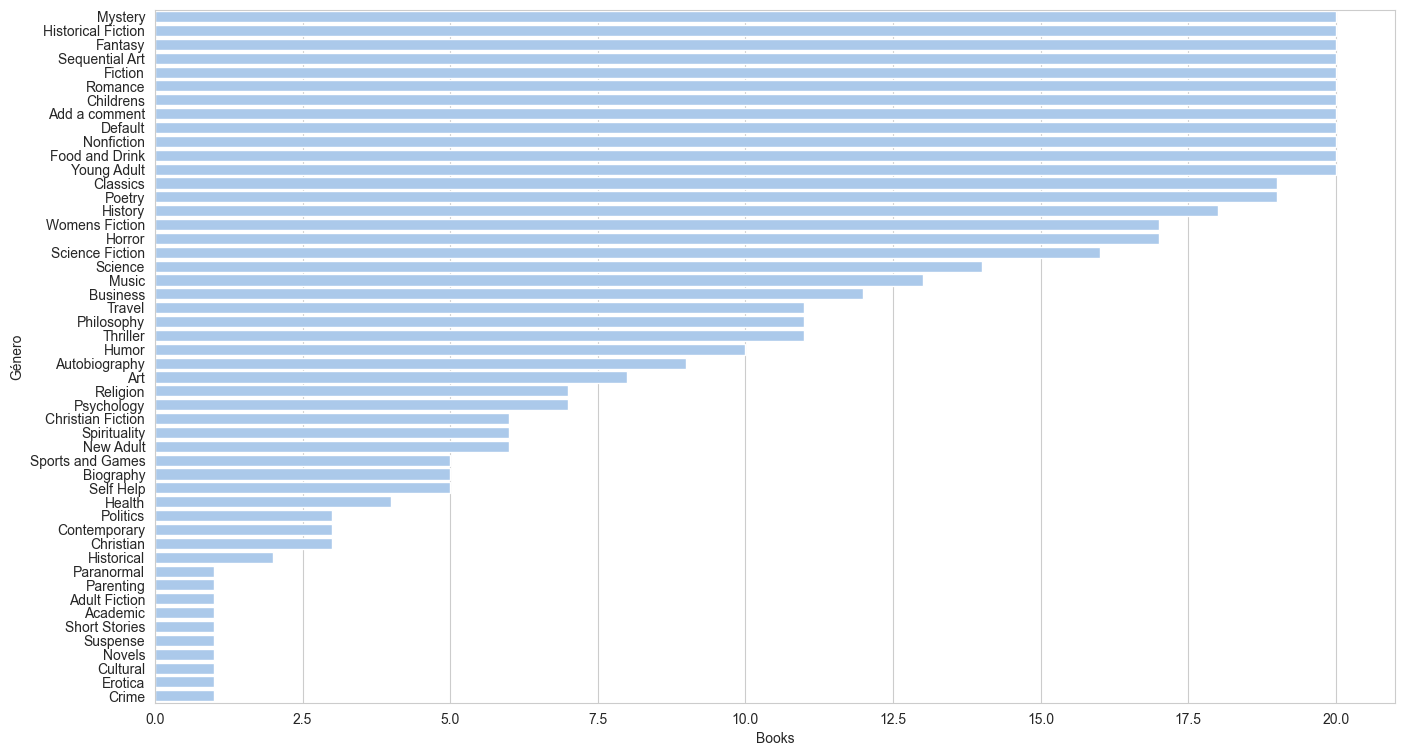

In [43]:
plt.figure(figsize=(16, 9))
sns.barplot(data=cat_book,y='Categoria',x='count')
plt.xlabel('Books')
plt.ylabel('Género')

*Costo promedio por categoria*

In [53]:
books_df.Estrellas.unique()


array(['Two', 'Four', 'Three', 'One', 'Five'], dtype=object)

In [55]:
map_star={'Two':2, 'Four':4, 'Three':3, 'One':1, 'Five':5}

In [56]:
books_df['value_estrellas']= books_df['Estrellas'].map(map_star)

In [50]:
books_df.groupby('Categoria',as_index=False)['Precio'].mean().round(2).sort_values(by='Precio',ascending=False)

,Categoria,Precio
45,Suspense,58.33
29,Novels,54.81
34,Politics,53.61
19,Health,51.45
27,New Adult,46.38
8,Christian,42.50
44,Sports and Games,41.17
40,Self Help,40.62
47,Travel,39.79
16,Fantasy,39.65


*Rating promedio por categoria*

In [58]:
books_df.groupby('Categoria',as_index=False)['value_estrellas'].mean().round(2).sort_values(by='value_estrellas',ascending=False)

,Categoria,value_estrellas
15,Erotica,5.00
2,Adult Fiction,5.00
29,Novels,5.00
9,Christian Fiction,4.17
19,Health,3.75
3,Art,3.62
33,Poetry,3.53
17,Fiction,3.45
24,Humor,3.40
43,Spirituality,3.33


*¿Existe relación entre el precio y la valuación?*

In [64]:
books_df[['value_estrellas','Precio']].corr().round(2)

,value_estrellas,Precio
value_estrellas,1.00,0.02
Precio,0.02,1.00


<Axes: xlabel='Precio', ylabel='value_estrellas'>

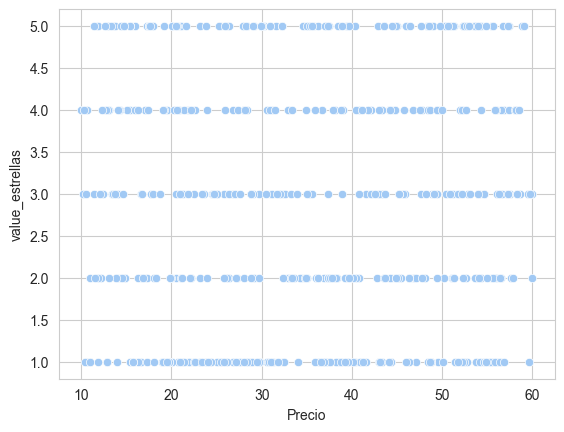

In [61]:
sns.scatterplot(data=books_df,x='Precio',y='value_estrellas')

*¿Existe relación entre la categoria y el costo?*

<Axes: xlabel='Precio', ylabel='Categoria'>

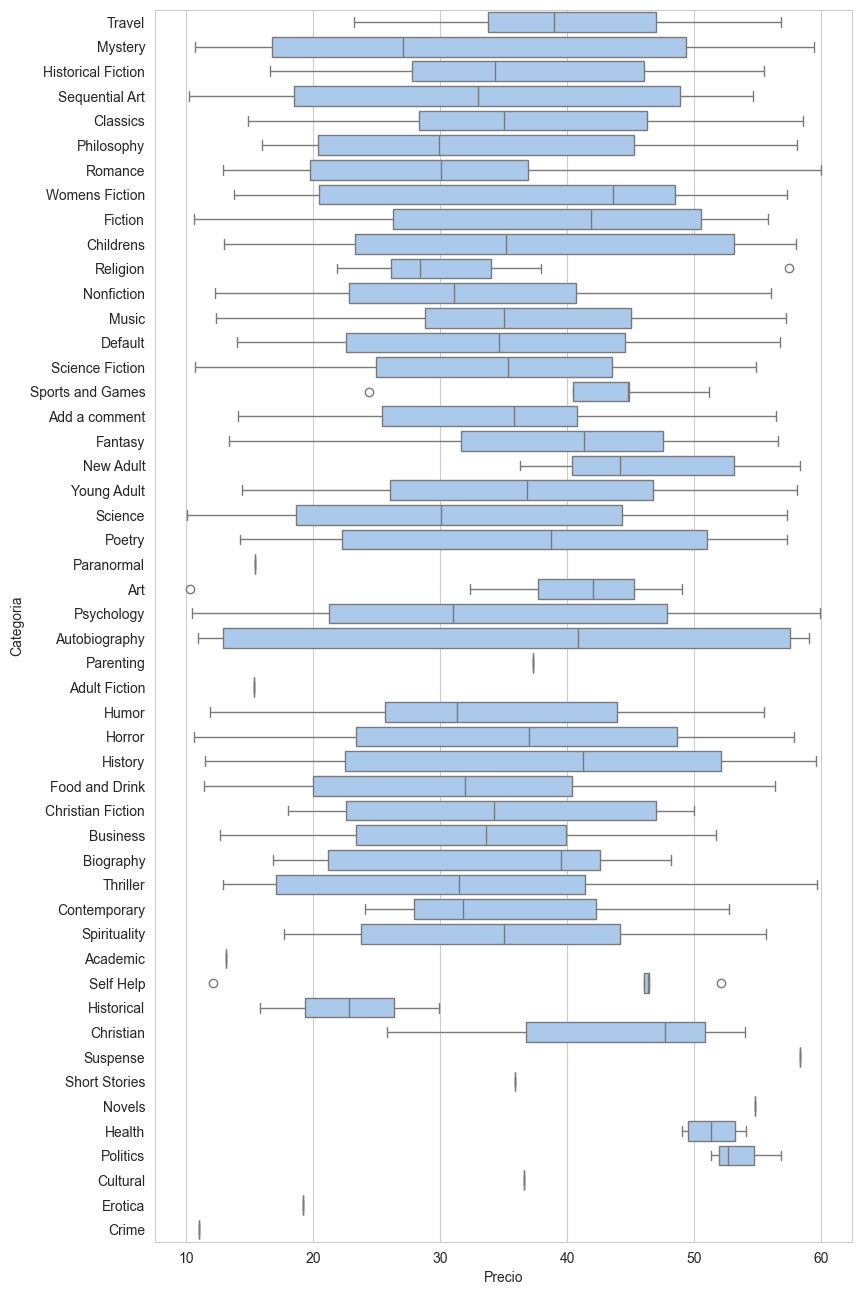

In [66]:
plt.figure(figsize=(9, 16))
sns.boxplot(data=books_df,x='Precio',y='Categoria')

*¿Existe relación entre precio promedio con respecto a la puntuación promedio por categoria?*

In [68]:
grouped=books_df.groupby('Categoria',as_index=False).agg(
    precio_avg =('Precio','mean'),
    rating_avg=('value_estrellas','mean')
)


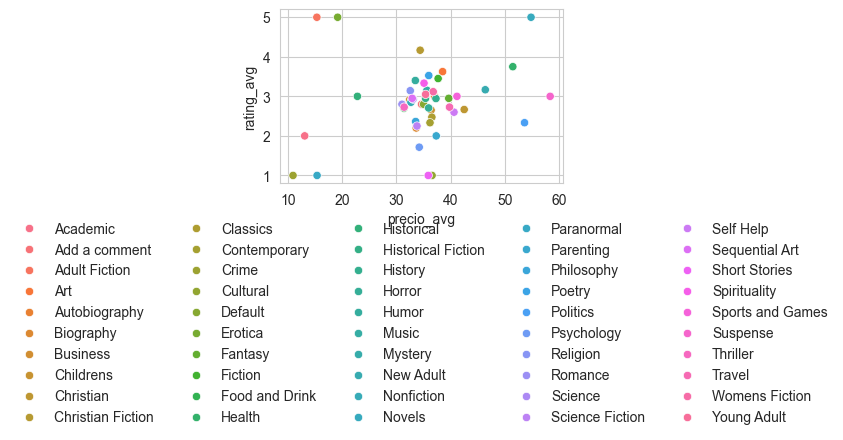

In [ ]:
sns.scatterplot(data=grouped,x='precio_avg',y='rating_avg')


### Conclusiones

*Escribe aqui tus conclusiones*

### Compartir resultados

**Instrucciones**

*Carga tu reporte en GitHub, incluye en el repositorio un archivo README donde describas el objetivo del estudio*


Puedes utilizar la siguiente estructura para el `README` de tu repo, ajústalo a tu preferencia:

```bash
# Proyecto de Web Scraping: Análisis de "Books to Scrape"

## 1. Contexto del Proyecto

Este proyecto se enfoca en la aplicación de técnicas de **Web Scraping** para extraer información valiosa del sitio web [Books to Scrape](http://books.toscrape.com/), un entorno de pruebas seguro diseñado para practicar la recolección de datos web.

El objetivo principal es recolectar, estructurar y analizar datos de un catálogo de libros para obtener insights, como la distribución de libros por categoría, el análisis de precios y la popularidad basada en las calificaciones.

## 2. Proceso y Técnicas Utilizadas

Para llevar a cabo este análisis, se siguió un flujo de trabajo estructurado que combina la extracción de datos con el análisis exploratorio (EDA).

### Técnicas de Web Scraping:

-   **Peticiones HTTP (`requests`):** Se utilizó la librería `requests` de Python para conectarse al servidor del sitio web y obtener el contenido HTML de las páginas.
-   **Análisis de HTML (`BeautifulSoup`):** Con `BeautifulSoup`, se analizó la estructura del documento HTML para localizar y extraer de manera sistemática la información de interés de cada libro, como:
    -   Título
    -   Precio
    -   Calificación por estrellas
    -   Categoría

### Análisis de Datos:

-   **Manipulación de Datos (`pandas`):** Los datos extraídos fueron organizados y limpiados utilizando `pandas`. Se creó un DataFrame para facilitar la manipulación y el análisis posterior, incluyendo la conversión de tipos de datos y la gestión de valores.
-   **Visualización de Datos (`matplotlib` y `seaborn`):** Para comunicar los hallazgos, se generaron visualizaciones claras y efectivas que muestran:
    -   La cantidad de libros disponibles por categoría.
    -   El precio promedio de los libros en diferentes géneros.
    -   La distribución de las calificaciones a lo largo del catálogo.
```


Tambien considera la siguiente estructura para tu proyecto

```bash 
/proyecto-web-scraping
|
├── .gitignore             # Archivo para ignorar archivos y carpetas en Git (como .venv, __pycache__, etc.)
├── README.md              # La documentación principal del proyecto que acabamos de describir.
├── requirements.txt       # Un archivo de texto con las librerías de Python necesarias (ej. pandas, requests, beautifulsoup4).
|
├── notebooks/
│   └── web_scraping_analisis.ipynb  # Tu notebook principal, donde se realiza todo el trabajo.
|
├── data/
│   └── processed/
│       └── catalogo_libros.csv # Es una buena práctica guardar los datos extraídos en un archivo CSV.
|
└── output/
    └── images/
        └── libros_por_categoria.png # Carpeta para guardar los gráficos o imágenes generadas.

```

## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta el proyecto nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [Sprint 8](https://discord.com/channels/1081207584104656986/1270074133648113694).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal `#project` para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨